In [1]:
from typing import Annotated, Sequence, TypedDict, NotRequired

from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage, BaseMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from pydantic import SecretStr

from operator import add
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENROUTER_BASE_URL = os.getenv("OPENROUTER_BASE_URL")

if OPENAI_API_KEY is None:
    raise ValueError("There isn't any api key")

# 0. Creating API-ref for LLM
model_qwen = ChatOpenAI(
    api_key = SecretStr(OPENAI_API_KEY),
    base_url = OPENROUTER_BASE_URL,
    model = "qwen/qwen-2.5-72b-instruct"
)

# Typing the state

In [3]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    document_content: NotRequired[str]

# Creating Tools

In [4]:
@tool
def update(content:str) -> str:
    """Use this tool to create a new document or replace the entire document.
    
    Args:
        content (str): New text of the document
    """
    return content

@tool
def save(filename: str, content: str) -> str:
    """Save the current document to a text file and finish the process
    
    Args:
        filename (str): Name for the text file.
    """

    if not filename.endswith(".txt"):
        filename = f"{filename}.txt"
    
    try:
        with open(filename, 'w') as file:
            file.write(content)
        return f"Document has been saved successfully to '{filename}'."
    
    except Exception as e:
        return f"Error saving document: {str(e)}"
    
tools = [update, save]
tool_model_qwen = model_qwen.bind_tools(tools=tools)

# Creating Nodes

In [5]:
# agent node
def our_agent(state: AgentState) -> dict:
    "Node for chating with agent"
    system_prompt = SystemMessage(content=f"""You are Drafter, a helpful writing assistant.
    Your job is to help the user create, update, and save text documents.

    If the user wants to create or modify the document, call the 'update' tool with the full new document content.
    - If the user wants to save and finish, call the 'save' tool.
    - When calling 'save', always pass:
        - 'filename': the requested filename
        - 'content': the current full document content
    - After each update, explain briefly what changed and show the current document content.

    The current document content is: {state.get("document_content", "")}
    """)

    all_messages = [system_prompt] + list(state["messages"])
    response = tool_model_qwen.invoke(all_messages)

    return {"messages": [response]}

# document updating node
def update_document(state: AgentState) -> dict:
    messages = state["messages"]
    
    if not messages:
        return {}
    
    last_message = messages[-1]


    if (
        isinstance(last_message, ToolMessage)
        and last_message.name == "update"
        and isinstance(last_message.content, str)
    ):
        return {"document_content": last_message.content}
    return {}

# conditional edge
def should_continue(state: AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state["messages"]

    if not messages:
        return "continue"

    last_message = messages[-1]

    if isinstance(last_message, ToolMessage) and last_message.name == "save":
        return "end"

    return "continue"
    
def tools_router(state: AgentState) -> str:
    messages = state["messages"]

    if not messages:
        return "end"
    
    last_message = messages[-1]

    if (isinstance(last_message, AIMessage) and
        hasattr(last_message, "tool_calls") and
        last_message.tool_calls):
        return "tools"

    return "end"


# Creating graph

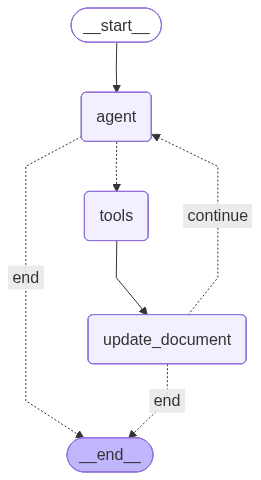

In [6]:
graph = StateGraph(AgentState)

# nodes
graph.add_node("agent", our_agent)
graph.add_node("tools", ToolNode(tools=tools))
graph.add_node("update_document", update_document)

# edges
graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent",
    tools_router,
    {
        "end": END,
        "tools": "tools"
    }
)
graph.add_edge("tools", "update_document")
graph.add_conditional_edges(
    "update_document",
    should_continue,
    {
        "continue": "agent",
        "end": END
    }
)

app = graph.compile(checkpointer=MemorySaver())
app


In [7]:
cfg: RunnableConfig = {"configurable": {"thread_id": "id_0"}}

def run_document_agent():
    print("\n===== DRAFTER =====")
    print("Hello. I'm DRAFTER and I'm ready to help you create and update a document.")
    
    while True:
            user_text = input("\n> ").strip()

            if user_text.lower() == "exit":
                break

            if not user_text:
                continue

            prev_len = 0
            state_snapshot = app.get_state(cfg)
            if state_snapshot and state_snapshot.values and "messages" in state_snapshot.values:
                prev_len = len(state_snapshot.values["messages"])

            for event in app.stream(
                {"messages": [HumanMessage(content=user_text)]},
                stream_mode="values",
                config=cfg
            ):
                if "messages" in event and len(event["messages"]) > prev_len:
                    event["messages"][-1].pretty_print()
                    prev_len = len(event["messages"])

            final_state = app.get_state(cfg).values
            last_message = final_state["messages"][-1]

            if isinstance(last_message, ToolMessage) and last_message.name == "save":
                break

    print("\n===== DRAFTER FINISHED =====")

In [8]:
run_document_agent()


===== DRAFTER =====
Hello. I'm DRAFTER and I'm ready to help you create and update a document.
================================ Human Message =================================

can you write email for me?
================================== Ai Message ==================================

Of course! Could you please provide me with the details you'd like to include in the email, such as the recipient, the purpose of the email, and any specific information or points you want to cover?
================================ Human Message =================================

create an email that says I cannot to accept the metting for John
================================== Ai Message ==================================
Tool Calls:
  update (call_dd8c7e0b645948d28f3ae9)
 Call ID: call_dd8c7e0b645948d28f3ae9
  Args:
    content: Subject: Regretfully Declining Meeting Request

Dear John,

I hope this message finds you well. Thank you for the invitation to join the meeting scheduled for [Date and Time]